# Figure 3.3-1 &mdash; the steam charts, drawn from Appendix A.III

Figure 3.3-1 is two full-page property charts for steam: **(a)** the
enthalpy&ndash;entropy or **Mollier** diagram, and **(b)** the temperature&ndash;entropy
diagram. This notebook draws both of them, and it draws them from the steam tables
printed in **Appendix A.III of this book** &mdash; so a value you read off a chart and a
value you look up in the table cannot disagree.

**Why run this rather than read the printed page?** A printed chart is one chart at one
scale. Here you can

- **zoom in** on the corner your problem lives in, at any scale you like, instead of
  reading a crowded full-page chart with a ruler;
- **read a number off the curve** instead of interpolating by eye &mdash; every family
  of lines is a function you can evaluate;
- **draw your own path** on the chart, as &sect;5 does for Illustration 3.4-1, and see
  the process rather than just its endpoints;
- **decide how busy the chart is.** Every line family is an argument. Turn the minor
  isobars off, put isotherms every 25 &deg;C instead of 50, and print the result.

**What this notebook does**

1. loads Appendix A.III as data, and checks the digitization against an identity the
   table must satisfy;
2. builds the four families of lines a property chart is made of &mdash; saturation,
   isobars, isotherms, constant quality (and constant enthalpy for the $T$&ndash;$S$
   chart);
3. draws both charts;
4. reads **Illustration 3.4-1** off them &mdash; the Joule&ndash;Thomson expansion the
   text solves *using these two figures* &mdash; and compares with the book's answer.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst<br>
August 2026

In [1]:
# --- Colab bootstrap -------------------------------------------------------
# No-op when the thermo package and the steam tables are already alongside this
# notebook (the normal case: you cloned the repository and are running from
# code/ch3/). In Colab there is no repository, so fetch both.
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    # rm -rf first: git clone REFUSES an existing directory, and under `!` that
    # failure is silent -- a half-finished earlier clone would otherwise leave an
    # empty thermo/ and surface as a baffling ImportError further down.
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
else:
    sys.path.insert(0, '..')
# ---------------------------------------------------------------------------

## 1. Where the numbers come from, and why not an equation of state

The obvious way to draw a steam chart is from an equation of state. Two reasons not to:

- **A cubic will not do it.** The chapter 7 water notebook establishes that
  Peng&ndash;Robinson is **21% off** on the vapor pressure of water at the triple
  point, and $\hat H$ and $\hat S$ are harder than vapor pressure. A chart is read to
  better than 2%.
- **IAPWS-IF97 *would* do it, and is still the wrong choice here.** It is a few hundred
  lines with no new dependency. But it would create a **second source of truth**: a
  chart whose numbers disagree in the last digit with the appendix you are reading it
  against. These charts exist to be used for solving problems, and the problems are
  solved from A.III.

So the chart is drawn from A.III itself, which makes it **consistent with the table by
construction**. What A.III contains:

| | |
|---|---|
| saturation, temperature table | 71 rows, 0.01&ndash;374.14 &deg;C |
| saturation, pressure table | 73 rows |
| superheated vapor | **545 points** on **36 isobars** (0.01&ndash;60 MPa), 25 temperature levels (50&ndash;1300 &deg;C) |
| compressed liquid | 111 points on 6 isobars |
| saturated solid&ndash;vapor | 22 rows |

36 isobars is more than a classic Mollier chart plots.

&#9888; **Two things to know about this data.**

- **A.III is not IAPWS.** The appendix is reproduced in the book from Van Wylen &
  Sontag (Wiley, 1978), so it is that generation of steam tables and differs from
  current NIST values in the last digit or two. For a chart you read *against the
  appendix* that is not a defect, it is the requirement &mdash; but it does mean
  nothing drawn here may be labeled IAPWS. If A.III is ever updated, the chart
  regenerates for free.
- **The printed table groups digits with a thin space** (`0.194 44`, `0.001 285 9`).
  A whitespace tokenizer splits those in two and silently shifts every column to the
  right of them &mdash; producing corrupted isobars that still look like plausible
  curves. `tools/parse_appendix_A3.py`, which produced these CSVs, cuts columns by position
  rather than by counting tokens, and then verifies every row against
  $P\hat V = \hat H - \hat U$, which is the check the next cell repeats.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

from thermo.charts import use_book_style
from thermo.steam_chart import (SteamTables, mollier, temperature_entropy,
                                TC, PC, HC, SC, P_TRIPLE, R_M)

use_book_style()          # Computer Modern, with real TeX if it is installed

# Appendix A.III, digitized: the four tables the charts are drawn from. SteamTables
# loads them and builds the dome interpolators.
st = SteamTables()
sat, sh, cl, solid = st.sat, st.sh, st.cl, st.solid
dome, Tsat_of_P, ALL_P = st.dome, st.Tsat_of_P, st.ALL_P

print(f"reading Appendix A.III from {st.data_dir}/")
print(f"  saturation : {len(sat)} rows, {sat.T_C.min()}-{sat.T_C.max()} C")
print(f"  superheat  : {len(sh)} points, {sh.P_MPa.nunique()} isobars, "
      f"{sh.T_C.nunique()} temperature levels")
print(f"  compr. liq.: {len(cl)} points, {cl.P_MPa.nunique()} isobars")

reading Appendix A.III from /Users/furst/Desktop/CBET-6e/code/data/
  saturation : 71 rows, 0.01-374.14 C
  superheat  : 545 points, 36 isobars, 25 temperature levels
  compr. liq.: 111 points, 6 isobars


### The check that catches a bad parse

Enthalpy, internal energy and volume are not independent: $\hat H = \hat U + P\hat V$.
Every row of the superheat and compressed-liquid tables must satisfy it, and the
saturation rows must also satisfy $\Delta\hat X = \hat X^{\mathrm V} - \hat X^{\mathrm L}$.
Neither identity involves any correlation or fit &mdash; they are arithmetic the printed
table has to obey, so a column that has been shifted by one cannot pass them.

In [3]:
def check_PV(df, label):
    """P*V = H - U for every row, in kJ/kg.  Returns the rows that fail."""
    d = df.dropna(subset=["V", "U", "H"]).copy()
    d["PV"] = d.P_MPa * 1e3 * d.V          # MPa * m3/kg = 1e3 kJ/kg
    d["H_minus_U"] = d.H - d.U
    d["error"] = d.PV - d.H_minus_U
    bad = d[d.error.abs() > np.maximum(0.35, 2e-3 * d.H_minus_U.abs())]
    print(f"{label}: {len(d)} rows checked, {len(bad)} fail  "
          f"(worst residual {d.error.abs().max():.2f} kJ/kg)")
    return bad[["P_MPa", "T_C", "V", "U", "H", "PV", "H_minus_U", "error"]]


bad = pd.concat([check_PV(sh, "superheated vapor"),
                 check_PV(cl, "compressed liquid ")])
print()
print("every row consistent" if bad.empty else
      bad.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

superheated vapor: 545 rows checked, 0 fail  (worst residual 0.29 kJ/kg)
compressed liquid : 111 rows checked, 0 fail  (worst residual 0.09 kJ/kg)

every row consistent


### Every row passes &mdash; and why that is worth running before anything is drawn

Both tables are consistent to the last printed digit.

The identity is arithmetic, so there are only two ways a row can fail it: a number
went into the wrong column, or the number itself is wrong. **Neither is visible in a
plot.** An isobar built from a column that has been shifted by one row is still a
smooth, plausible-looking curve &mdash; which is exactly why it has to be caught here
rather than by eye at the end. Try it: shift `sh.U` by one row and re-run the cell
above, and watch hundreds of rows fail at once.

The check is also *local*. A single mistyped digit fails one row and nothing else, by
an amount you can convert straight back into the digit that moved: if
$P\hat V - (\hat H - \hat U)$ is 200 kJ/kg on one row of the 10 MPa isobar and zero on
both of its neighbors, that row's $\hat U$ is short by 200 &mdash; it is not the parse.

In [4]:
# A second, independent check: ten values typed by hand off the printed page, at
# pressures on both sides of the thin-space grouping that the parser has to rejoin.
printed = pd.DataFrame([
    #  P MPa    T C     V printed     U        H        S
    (  0.010,    50.0, 14.869,     2443.9,  2592.6,  8.1749),
    (  0.10,    100.0,  1.6958,    2506.7,  2676.2,  7.3614),
    (  1.00,    200.0,  0.2060,    2621.9,  2827.9,  6.6940),
    (  1.20,    250.0,  0.19234,   2704.2,  2935.0,  6.8294),   # 0.192 34
    (  2.00,    400.0,  0.15120,   2945.2,  3247.6,  7.1271),   # 0.151 20
    (  5.00,    500.0,  0.06857,   3091.0,  3433.8,  6.9759),   # 0.068 57
    ( 10.00,    650.0,  0.04101,   3338.2,  3748.2,  7.0398),   # 0.041 01, printed "0l"
    ( 20.00,    800.0,  0.02385,   3592.7,  4069.7,  7.0544),   # 0.023 85
    ( 40.00,    500.0,  0.005622,  2678.4,  2903.3,  5.4700),   # 0.005 622
    ( 60.00,   1300.0,  0.012215,  4551.4,  5284.3,  7.4837),   # 0.012 215
], columns=["P_MPa", "T_C", "V", "U", "H", "S"])

key = ["P_MPa", "T_C"]
merged = printed.merge(sh, on=key, suffixes=("_printed", "_parsed"))
assert len(merged) == len(printed), "a spot-check row did not survive the parse"
for c in ("V", "U", "H", "S"):
    merged[f"d{c}"] = merged[f"{c}_parsed"] - merged[f"{c}_printed"]

worst = max(merged[f"d{c}"].abs().max() for c in ("V", "U", "H", "S"))
print(merged[key + [f"{c}{s}" for c in ("V", "U", "H", "S")
                    for s in ("_printed", "_parsed")]].to_string(index=False))
print(f"\nlargest disagreement with the printed page: {worst:.3g}"
      f"  ({'exact to every printed digit' if worst == 0 else 'CHECK THIS'})")

 P_MPa    T_C  V_printed  V_parsed  U_printed  U_parsed  H_printed  H_parsed  S_printed  S_parsed
  0.01   50.0  14.869000 14.869000     2443.9    2443.9     2592.6    2592.6     8.1749    8.1749
  0.10  100.0   1.695800  1.695800     2506.7    2506.7     2676.2    2676.2     7.3614    7.3614
  1.00  200.0   0.206000  0.206000     2621.9    2621.9     2827.9    2827.9     6.6940    6.6940
  1.20  250.0   0.192340  0.192340     2704.2    2704.2     2935.0    2935.0     6.8294    6.8294
  2.00  400.0   0.151200  0.151200     2945.2    2945.2     3247.6    3247.6     7.1271    7.1271
  5.00  500.0   0.068570  0.068570     3091.0    3091.0     3433.8    3433.8     6.9759    6.9759
 10.00  650.0   0.041010  0.041010     3338.2    3338.2     3748.2    3748.2     7.0398    7.0398
 20.00  800.0   0.023850  0.023850     3592.7    3592.7     4069.7    4069.7     7.0544    7.0544
 40.00  500.0   0.005622  0.005622     2678.4    2678.4     2903.3    2903.3     5.4700    5.4700
 60.00 1300.0   0.01

## 2. From 616 tabulated points to the lines on a chart

The curve families &mdash; isobars, isotherms, lines of constant quality and of constant
enthalpy, and the liquid branches &mdash; are built by **`thermo.steam_chart`**, and the
draughtsmanship by **`thermo.charts`**. Both are commented at length; read them for the craft.

**Why they are not in this notebook.** `c05uf001`, the Rankine cycle of Illustration 5.2-1, is
this chart with a process path on it, and it belongs to chapter&nbsp;5. A figure's notebook lives
in its own chapter, so the machinery has to sit where both can reach it &mdash; otherwise there
are two copies and the first redraw makes them disagree.

**The hard part is not the thermodynamics, it is where a curve stops.** Several families are
built from two different tables and have to *meet*, exactly, on the saturation curve. Below
0.01&nbsp;MPa the superheat table simply ends, and the curves are continued on the ideal-gas
limit &mdash; anchored on states the appendix does tabulate, not extrapolated from the chart's
own lines. And a line of constant enthalpy can exist over two disjoint pressure ranges, so
joining its points into one polyline would draw a chord clear across the chart.

### Checking the two continuations before drawing with them

Both charts draw a line or two beyond where the table stops, and neither is worth
drawing unless it can be checked first.

**The isotherms, below 0.01 MPa.** Predict the tabulated 0.01 MPa point from the
0.1 and 0.05 MPa points &mdash; a *longer* reach in $\ln P$ than any extension the
chart draws &mdash; and compare.

**The 60 MPa liquid branch, beyond the 50 MPa column.** This one has a better test
than a leave-one-out: extrapolate the compressed-liquid table to 60 MPa at 380
&deg;C, and compare with the *superheated* table's own 60 MPa entry at 375 &deg;C.
That is a different table, at a temperature the extrapolation never saw.

In [5]:
# Is the low-pressure continuation good enough to draw? Test it where the answer is
# known: predict the tabulated 0.01 MPa point from the 0.1 and 0.05 MPa points, and
# compare. That is a bigger extrapolation in log P than any the chart actually makes.
rows = []
for T in (100, 200, 300, 500, 800):
    g = sh[(sh.T_C == T) & sh.P_MPa.isin([0.1, 0.05, 0.01])].sort_values("P_MPa")
    (P0, S0, H0), (P1, S1, H1), (P2, S2, H2) = [
        (r.P_MPa, r.S, r.H) for r in g.itertuples()]   # 0.01, 0.05, 0.1 MPa:
    # predict P0 (the lowest) from the two above it, the direction the chart extends
    dHdP = (H2 - H1) / (P2 - P1)
    rows.append({"T (C)": T,
                 "S predicted": S1 - R_M * np.log(P0 / P1), "S table": S0,
                 "H predicted": H1 + dHdP * (P0 - P1), "H table": H0})

pred = pd.DataFrame(rows)
pred["dS"] = pred["S predicted"] - pred["S table"]
pred["dH"] = pred["H predicted"] - pred["H table"]
print(pred.to_string(index=False, float_format=lambda v: f"{v:9.4f}"))

# what those errors are worth on the page, on a 5 x 2200 frame drawn 7.5 x 9.5 in
print(f"\nworst error, as a fraction of a 1-point line width on the printed chart:")
print(f"  entropy  {pred.dS.abs().max():.4f} kJ/kg K  "
      f"-> {pred.dS.abs().max() / 5.0 * 7.5 * 72:.1f} pt")
print(f"  enthalpy {pred.dH.abs().max():.2f} kJ/kg     "
      f"-> {pred.dH.abs().max() / 2200 * 9.5 * 72:.1f} pt")

# --- and the 60 MPa liquid branch, against a table it was not built from ------
print("\n60 MPa liquid branch, extrapolated from the 30 and 50 MPa columns:")
for prop in ("S", "H"):
    p = st.CL.pivot_table(index="T_C", columns="P_MPa", values=prop)
    a, b = p.loc[380, 30.0], p.loc[380, 50.0]
    got = b + (b - a) / 20 * 10
    tab = sh[(sh.P_MPa == 60) & (sh.T_C == 375)][prop].iloc[0]
    print(f"  {prop} at 380 C -> {got:9.4f}   vs the SUPERHEAT table's 60 MPa "
          f"at 375 C: {tab:9.4f}   ({got - tab:+.4f})")
print("  (the two should not match exactly -- they are 5 C apart -- but they bracket"
      "\n   the join, which is what the chart needs)")

 T (C)  S predicted   S table  H predicted   H table        dS        dH
   100       8.4375    8.4479    2687.5400 2687.5000   -0.0104    0.0400
   200       8.9008    8.9038    2879.6200 2879.5000   -0.0030    0.1200
   300       9.2801    9.2813    3076.4600 3076.5000   -0.0012   -0.0400
   500       9.8974    9.8978    3489.1800 3489.1000   -0.0004    0.0800
   800      10.6280   10.6281    4159.1400 4159.0000   -0.0001    0.1400

worst error, as a fraction of a 1-point line width on the printed chart:
  entropy  0.0104 kJ/kg K  -> 1.1 pt
  enthalpy 0.14 kJ/kg     -> 0.0 pt

60 MPa liquid branch, extrapolated from the 30 and 50 MPa columns:
  S at 380 C ->    3.7146   vs the SUPERHEAT table's 60 MPa at 375 C:    3.7141   (+0.0004)
  H at 380 C -> 1701.1500   vs the SUPERHEAT table's 60 MPa at 375 C: 1699.5000   (+1.6500)
  (the two should not match exactly -- they are 5 C apart -- but they bracket
   the join, which is what the chart needs)


### Labeling: the part that is chart craft rather than thermodynamics

An unlabeled chart is a mesh of curves. Making it readable is two separate jobs:
tell the families apart, and say which line is which. The first is line weight and dash
pattern, which is one dictionary. The second needs a little machinery, because a label
has to sit **on** its own curve and be rotated to that curve's slope *as drawn on the
page* &mdash; not in data units, which would tilt every label wrongly the moment you
change the axis limits.

## 3. Figure 3.3-1(a) &mdash; the Mollier ($\hat H$&ndash;$\hat S$) diagram

The frame is the ASME chart's: entropy 4.5 to 9.5 kJ/(kg K), enthalpy 2000 to 4200
kJ/kg, on a full page &mdash; taller than it is wide. That window is not arbitrary: it
is the turbine-expansion region, which is what a Mollier diagram is *for*.

**Two tiers per family.** Each family is drawn twice: a **labeled major set**, heavier,
and an **unlabeled minor set** between them, lighter &mdash; so the chart is dense
enough to read a value off, without every line competing for attention. All six sets are
arguments, and `LW` holds the weights; between them they decide how busy the chart is.

- the **saturated-vapor line** is the heaviest line on the chart, because everything
  else is read relative to it;
- **isobars** are solid and black &mdash; 12 labeled, the remaining 24 of the table's 36
  as thin lines between. Inside the dome an isobar is a *straight* line, since there
  $\mathrm{d}\hat H = T\,\mathrm{d}\hat S$ at constant $T$;
- **isotherms** are gray: every 100 &deg;C labeled, every 50 &deg;C drawn;
- **constant-quality** lines are gray and dashed, every 0.05 labeled.

Isobars are labeled in a fan across the top and the isotherms in a **key column down
the right-hand side**, which is where the ASME chart puts them too &mdash; now that the
isotherms run to the right edge, that column is the only place their labels can go
without landing on top of the isobars.

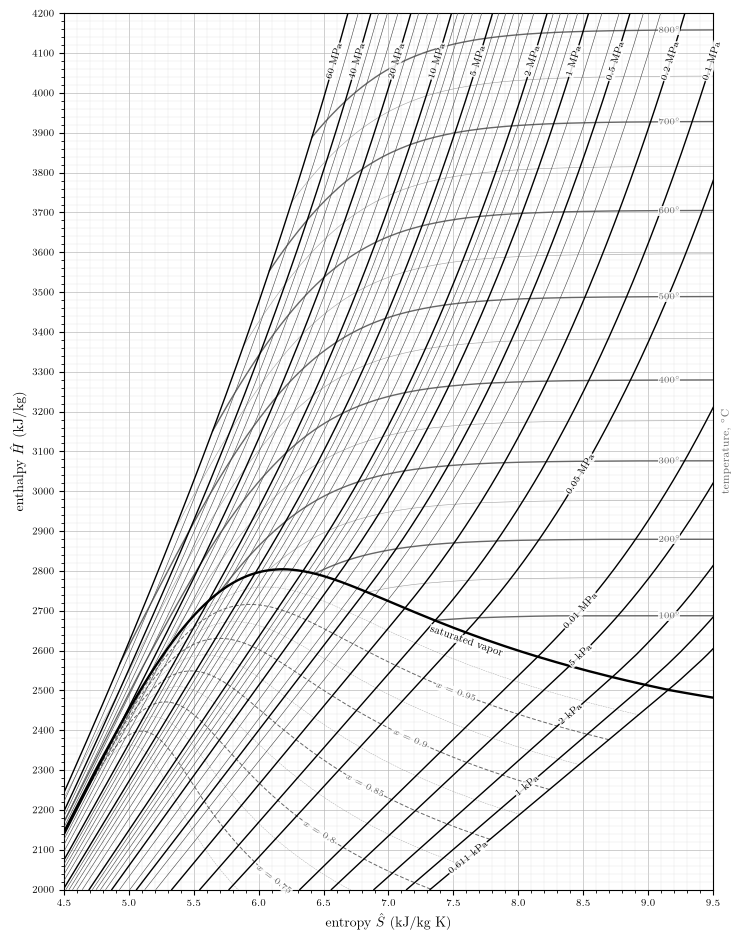

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 9.5))     # a full book page: height > width
mollier(ax, st)
fig.tight_layout()
os.makedirs("pdf", exist_ok=True)
fig.savefig("pdf/Fig_3.3-1a.pdf")     # the printed figure
plt.show()

## 4. Figure 3.3-1(b) &mdash; the temperature&ndash;entropy diagram

Same data, different projection, and it comes free: the saturation table is already
tabulated *against temperature*, so the dome is a direct plot. The frame is Keenan's:
entropy 0 to 10, temperature 0 to 800 &deg;C.

Two things this projection shows that the Mollier diagram cannot:

- inside the dome an isobar is **horizontal** &mdash; boiling at constant pressure is
  boiling at constant temperature. It is the same physical fact that makes the isobar
  straight on the Mollier chart, but here you can see it without being told.
- the compressed-liquid isobars, taken from the compressed-liquid table, pile onto the
  saturated-liquid line. That is the graphical version of the approximation the text
  uses constantly: for a liquid far from its critical point, properties barely depend
  on pressure.

The light curves are lines of **constant enthalpy** &mdash; the ones Illustration 3.4-1
follows in part (b). Inside the dome they are labeled *on the line*, in a row at
60 &deg;C: a line that never leaves the two-phase region runs down to the bottom of the
frame, so labeling it at its right-hand end would print the number on the temperature
axis. One member of the family is named as well as numbered &mdash; on the descending sweep of
the 3200 line, where the tilt makes it read as a label on that family &mdash; because
otherwise nothing on the chart says what 400 &hellip; 4000 are counting.

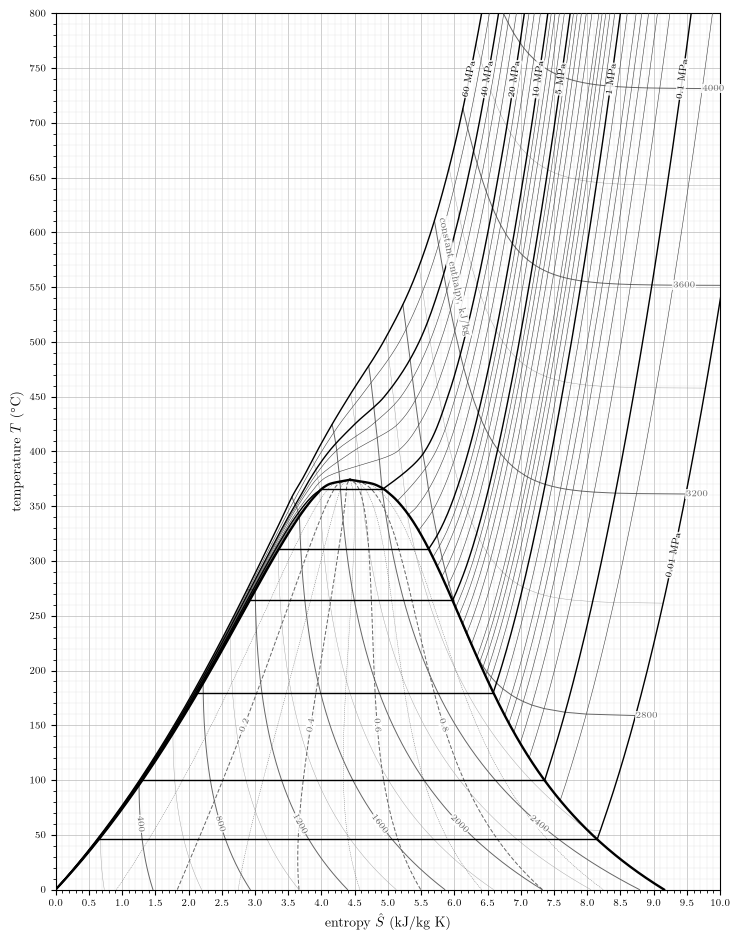

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 9.5))     # the same page shape as 3.3-1(a)
temperature_entropy(ax, st)
# No title: in the book the caption carries it. Add one if you are printing the chart
# on its own -- the light curves are constant enthalpy in kJ/kg, the dashed ones
# constant quality.
fig.tight_layout()
fig.savefig("pdf/Fig_3.3-1b.pdf")     # the printed figure
plt.show()

## 5. Does it work? Illustration 3.4-1, read off these charts

Illustration 3.4-1 is the book's own test of Fig. 3.3-1, and it is the first
illustration of &sect;3.4:

> Steam at 400 bar and 500 &deg;C undergoes a Joule&ndash;Thomson expansion to 1 bar.
> Determine the temperature of the steam after the expansion using **(a)** Fig. 3.3-1a,
> **(b)** Fig. 3.3-1b, **(c)** the steam tables of Appendix A.III.

A Joule&ndash;Thomson expansion is isenthalpic, so on the Mollier chart the path is a
**horizontal line** &mdash; which is exactly why the text reaches for that chart first.
The book reads $\hat H_1 \approx 2900$ kJ/kg off the chart, follows it to 1 bar, and
gets about 214 &deg;C; from the table in part (c) it gets 214.1 &deg;C.

The cell below does part (c) from the digitized table, then draws the path on both
charts. If the recomputed charts are usable, a reader must be able to get the same
answer off them.

In [8]:
P1, T1, P2 = 40.0, 500.0, 0.1      # 400 bar, 500 C, expanded to 1 bar

row = sh[(sh.P_MPa == P1) & (sh.T_C == T1)].iloc[0]
H1, S1 = row.H, row.S
print(f"state 1:  {P1:g} MPa, {T1:g} C   ->  H = {H1} kJ/kg, S = {S1} kJ/kg K")

# part (c): interpolate along the 1 bar isobar at constant enthalpy, the way the book
# does -- linearly between the two bracketing table rows
g = sh[(sh.P_MPa == P2) & sh.T_C.notna()].sort_values("T_C")
lo = g[g.H <= H1].iloc[-1]
hi = g[g.H >= H1].iloc[0]
T2_linear = lo.T_C + (hi.T_C - lo.T_C) * (H1 - lo.H) / (hi.H - lo.H)

# and along the monotone-cubic isobar the charts are drawn with
S_iso, H_iso, T_iso = st.isobar(P2)
T2_pchip = float(np.interp(H1, H_iso, T_iso))
S2 = float(np.interp(H1, H_iso, S_iso))

print(f"\nbracketing rows at {P2:g} MPa: "
      f"{lo.T_C:g} C -> {lo.H} kJ/kg, {hi.T_C:g} C -> {hi.H} kJ/kg")
print(f"  T2, linear interpolation (the book's part c) = {T2_linear:6.2f} C"
      f"   [book: 214.1 C]")
print(f"  T2, monotone cubic along the whole isobar    = {T2_pchip:6.2f} C")
print(f"  entropy generated by the expansion: "
      f"S2 - S1 = {S2 - S1:.3f} kJ/kg K  (positive, as it must be)")

state 1:  40 MPa, 500 C   ->  H = 2903.3 kJ/kg, S = 5.47 kJ/kg K

bracketing rows at 0.1 MPa: 200 C -> 2875.3 kJ/kg, 250 C -> 2974.3 kJ/kg
  T2, linear interpolation (the book's part c) = 214.14 C   [book: 214.1 C]
  T2, monotone cubic along the whole isobar    = 214.16 C
  entropy generated by the expansion: S2 - S1 = 2.423 kJ/kg K  (positive, as it must be)


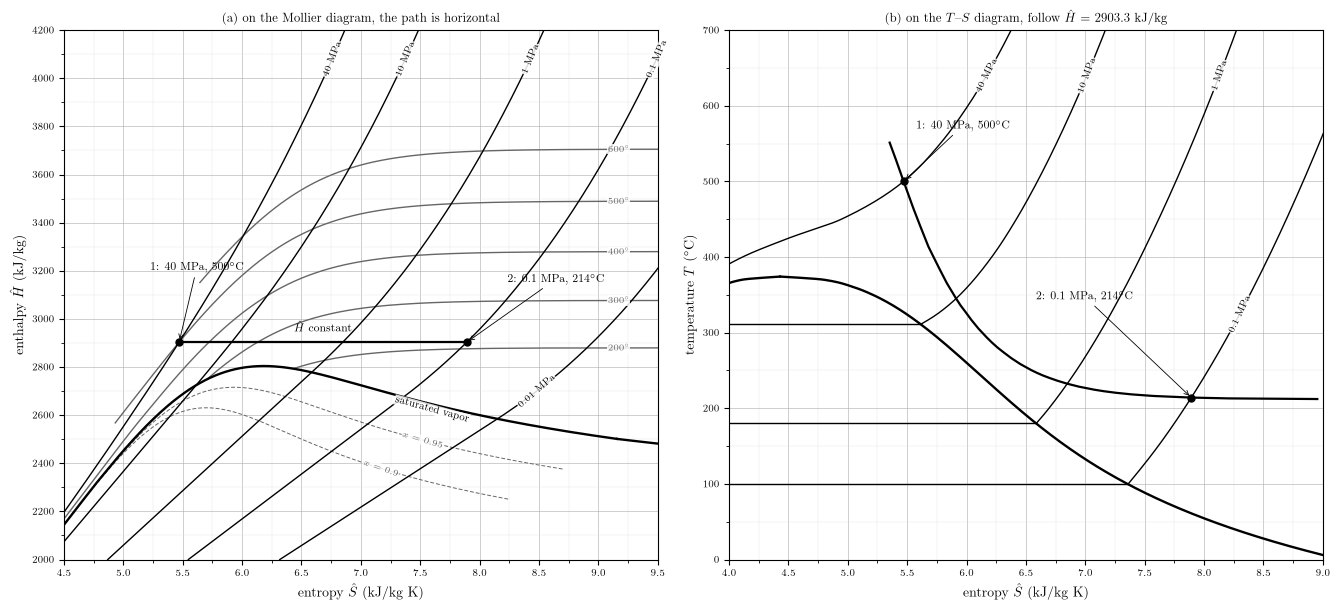

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.2))

# --- on the Mollier chart: the path is horizontal -------------------------
ax = axes[0]
# a deliberately sparse version of each chart: the minor line sets are turned off,
# because this panel is a demonstration of how the charts are read, not a chart to
# read values off
mollier(ax, st, isotherms=(200, 300, 400, 500, 600), isotherms_minor=(),
        qualities=(0.9, 0.95), qualities_minor=(),
        isobars=(0.01, 0.1, 1.0, 10.0, 40.0), isobars_minor=(),
        H_grid=200, grid_minors=2, T_key_title=False)
ax.plot([S1, S2], [H1, H1], "-", color="k", lw=1.6, zorder=7)
ax.plot([S1, S2], [H1, H1], "o", color="k", ms=5, zorder=7)
ax.annotate(f"1: {P1:g} MPa, {T1:g}$^\\circ$C", xy=(S1, H1),
            xytext=(S1 + 0.15, H1 + 300), fontsize=8, ha="center",
            arrowprops=dict(arrowstyle="->", lw=0.6))
ax.annotate(f"2: {P2:g} MPa, {T2_pchip:.0f}$^\\circ$C", xy=(S2, H1),
            xytext=(S2 + 0.75, H1 + 250), fontsize=8, ha="center",
            arrowprops=dict(arrowstyle="->", lw=0.6))
ax.text(0.5 * (S1 + S2), H1 + 45, "$\\hat H$ constant", fontsize=8, ha="center")
ax.set_title("(a) on the Mollier diagram, the path is horizontal", fontsize=9)

# --- on the T-S chart: follow the constant-enthalpy curve -----------------
ax = axes[1]
temperature_entropy(ax, st, isobars=(0.1, 1.0, 10.0, 40.0), isobars_minor=(),
                    isenthalps=(), isenthalps_minor=(),
                    qualities=(), qualities_minor=(),
                    S_lim=(4, 9), T_lim=(0, 700), mark_critical=False,
                    T_grid=100, grid_minors=2)
for S, T, _ in st.isenthalp(H1, sorted(sh.P_MPa.unique())):
    ax.plot(S, T, "-", color="k", lw=1.6, zorder=7)
ax.plot([S1, S2], [T1, T2_pchip], "o", color="k", ms=5, zorder=7)
ax.annotate(f"1: {P1:g} MPa, {T1:g}$^\\circ$C", xy=(S1, T1), xytext=(S1 + 0.5, T1 + 70),
            fontsize=8, ha="center", arrowprops=dict(arrowstyle="->", lw=0.6))
ax.annotate(f"2: {P2:g} MPa, {T2_pchip:.0f}$^\\circ$C", xy=(S2, T2_pchip),
            xytext=(S2 - 0.9, T2_pchip + 130), fontsize=8, ha="center",
            arrowprops=dict(arrowstyle="->", lw=0.6))
ax.set_title(f"(b) on the $T$--$S$ diagram, follow $\\hat H$ = {H1:g} kJ/kg",
             fontsize=9)

fig.tight_layout()
fig.savefig("pdf/Illustration_3.4-1_on_both_charts.pdf")
plt.show()

The path on the $T$&ndash;$S$ chart is the same curve the text describes: it drops
steeply at first and then flattens, and the temperature falls by only 286 &deg;C over a
400-fold drop in pressure. Both readings agree with the book's 214.1 &deg;C, and part
(c) reproduces it to the digit.

## What this notebook shows

- **A property chart is a table plus a drawing convention.** Nothing here is fitted or
  correlated. Every curve is a slice of Appendix A.III &mdash; a column, a row, a lever
  rule, or a root found along one of those &mdash; joined with a monotone interpolant.
- **Read a chart along the line the process follows.** A Joule&ndash;Thomson expansion
  is isenthalpic, so on the Mollier diagram it is a horizontal line and on the
  $T$&ndash;$S$ diagram it is a curve you must have drawn for you. That is the whole
  reason two projections of the same data are both printed: each makes a different
  family of processes into a straight line.
- **Data has to be checked before it is drawn.** Every row of A.III satisfies
  $P\hat V = \hat H - \hat U$, and the check is run before a single curve is plotted
  &mdash; because a parse that had shifted a column would have produced isobars that
  still looked like plausible curves. A plausible-looking curve is not evidence.
- **Say where a line stops being data.** Two families here are continued past the last
  tabulated point &mdash; the isotherms below 0.01 MPa and the 60 MPa liquid branch
  &mdash; and both continuations are tested against a table value they were not built
  from before anything is drawn with them.

## Your turn

1. **Read your own problem off the chart.** Problem 3.5 is Illustration 3.4-1 with
   different numbers: steam at 500 bar and 600 &deg;C, expanded to 1 bar. Redraw the
   &sect;5 panels for that state and read $T_2$ off both charts, then get it from the
   table the way part (c) does. How far apart are the three answers, and which digit is
   the first one you should not trust?
2. **Zoom in.** Redraw the Mollier chart with `S_lim=(6.5, 8.0)`, `H_lim=(2400, 3000)`
   and a finer grid (`S_grid=0.1`, `H_grid=25`). That is the wet-steam corner where a
   turbine exit lands. Read the quality of steam at 0.05 MPa and
   $\hat H = 2500$ kJ/kg off your chart, then check it against the lever rule and the
   saturation table.
3. **Make the chart denser, or sparser.** The ASME original labels isotherms every
   20 &deg;C. Move `MOLLIER_T` and `MOLLIER_T_MINOR` to a 25 &deg;C spacing, or strip
   the chart to the eight isobars and five isotherms you would actually use. Print both
   in black and white. Which one can you still read at arm's length, and which one is
   *legible* but no longer *useful*?
4. **Add the line your cycle needs.** Chapter 5 works with power and refrigeration
   cycles, whose four states you plot on the $T$&ndash;$S$ chart. Write a function that
   takes a list of $(P, T)$ states, plots them on `temperature_entropy` in order, and
   closes the loop. Try it on the Rankine cycle of Illustration 5.2-1: condenser at
   100 &deg;C, evaporator at 3.0 MPa, maximum temperature 600 &deg;C, pump and turbine
   reversible. Which of the four legs is vertical, and why?
5. **Break the isotherms on purpose.** In `isotherm`, build the curve by reading the
   table *rows* at that temperature instead of evaluating each isobar. Plot the 650
   &deg;C isotherm both ways. Where does the row-based one stop, and what does looking
   up 650 &deg;C in Appendix A.III tell you about why?
6. **Test a continuation the way &sect;2 does.** The low-pressure continuation assumes
   steam is an ideal gas below 0.01 MPa. Predict the tabulated 0.05 MPa point from the
   0.5 and 0.1 MPa points &mdash; a much longer reach &mdash; and find the temperature
   below which you would not trust it to a line width. What is it about low temperature
   that makes the assumption fail first there?

## 6. Where this chart is used

**`c05uf001`** &mdash; Illustration 5.2-1's Rankine power cycle &mdash; is this chart with the
cycle drawn on it, and it is built in **`code/ch5/Rankine_cycle_steam_figure.ipynb`** from the
same `thermo.steam_chart` machinery this notebook uses. It moves when this chart moves, and
there is only one copy of the code.

That notebook also carries the check that the chart works: every number in Illustration 5.2-1's
printed table reproduces from Appendix A.III, **including the 29.0 % efficiency** &mdash; except
the two interpolated temperatures, which are 5e errata the illustration's own Aspen output
already contradicted.

*(The methane and nitrogen charts, Figs. 3.3-2 and 3.3-3, come from
`PH_charts_methane_and_nitrogen.ipynb` instead: the book tabulates neither fluid, so those are
computed from the Peng&ndash;Robinson equation of state. Two figures derived from them,
Fig. 5.1-3 and `c06uf002`, live in chapters 5 and 6.)*

## What this notebook shows

- The book's own Appendix A.III is enough to draw both steam charts &mdash; **no equation of
  state, and no outside data source**. For water the book tabulates the properties, so a cubic
  would be a step backwards.
- The parse is checked against the table's **own identity**, $P\hat V = \hat H - \hat U$, which
  every row satisfies &mdash; a test no correlation or fit enters into.
- The continuations below 0.01 MPa are anchored on tabulated states rather than extrapolated,
  and the check two cells above tests them against data they are not built from.

## Your turn

- Read a state off either chart and check it against the tables: pick a pressure and
  temperature, find the point, and compare.
- Draw a process on the Mollier chart the way Illustration 3.4-1 does &mdash; a throttling
  valve is a horizontal line, an ideal turbine a vertical one.